In [235]:
import nest_asyncio
nest_asyncio.apply()  # Required for Gremlin driver in Jupyter (avoids "event loop already running" error)

from pathlib import Path
from dotenv import load_dotenv

# Load .env from agents folder
env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd() / 'backend' / 'agents' / '.env'
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"✓ Loaded .env from: {env_path}")
else:
    print("⚠ .env not found in agents folder")

✓ Loaded .env from: /Users/rob.bajra/Projects/voice-to-rag/backend/agents/.env


In [236]:
from puppygraph import PuppyGraphClient, PuppyGraphHostConfig
client = PuppyGraphClient(PuppyGraphHostConfig("localhost"))
client.gremlin_query("g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()")


[path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[651c8d73-4a3c-35e4-96ab-61df5aa15568]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[dcd982d2-5bd9-351f-bb31-0fca2278c9b9]][table[00vsdb.agent_analytics.agents_bronze]-lineage->table[00vsdb.agent_analytics.agents_clean]]]]

In [237]:

# Databricks model setup (E2 demo workspace)
from openai import OpenAI

ai_client = OpenAI(
  api_key=os.getenv("DATABRICKS_TOKEN"), # your personal access token
  base_url=os.getenv("DATABRICKS_HOST") + "serving-endpoints", # your Databricks workspace instance
)


In [238]:
# PuppyGraph tools (reload to pick up changes)
import importlib
import gremlin_tool
import graph_viz_tool
importlib.reload(gremlin_tool)
importlib.reload(graph_viz_tool)

from gremlin_tool import (
    GENERATE_GREMLIN_TOOL_SPEC, generate_gremlin,
    EXECUTE_GREMLIN_TOOL_SPEC, execute_gremlin,
)
from graph_viz_tool import (
    VISUALIZE_LINEAGE_TOOL_SPEC, visualize_lineage,
)

# Tool specs (dicts for the OpenAI API) and local functions
TOOLS = [GENERATE_GREMLIN_TOOL_SPEC, EXECUTE_GREMLIN_TOOL_SPEC, VISUALIZE_LINEAGE_TOOL_SPEC]



In [239]:
import json

def AGENT(user_query: str):
    # Map tool names to their local Python functions
    TOOL_FUNCTIONS = {
        "generate_gremlin": generate_gremlin,
        "execute_gremlin": execute_gremlin,
        "visualize_lineage": visualize_lineage,
    }

    LLM_ENDPOINT_NAME = "databricks-claude-sonnet-4-5"
    MAX_TOOL_ROUNDS = 5  # safety limit to avoid infinite loops

    messages = [
        {
            "role": "system",
            "content": """
            You are a PuppyGraph agent.
            Before each action, explain your reasoning step by step.
            Use the generate_gremlin tool to convert natural language questions into Gremlin queries.
            Then use the execute_gremlin tool to run the query and return results.
            Always call execute_gremlin after generate_gremlin to get the actual data.
            When the user asks about lineage, data flow, or graph relationships,
            also call visualize_lineage with the same Gremlin query to render an
            inline graph visualization.
            """,
        },
        {
            "role": "user",
            "content": user_query,
        },
    ]

    # Agentic loop: keep calling the LLM until it stops requesting tool calls
    for round_num in range(MAX_TOOL_ROUNDS):
        response = ai_client.chat.completions.create(
            messages=messages,
            model=LLM_ENDPOINT_NAME,
            tools=TOOLS,
            max_tokens=1024,
        )

        choice = response.choices[0]

        if choice.finish_reason != "tool_calls":
            # Model is done — print final answer
            print("Final answer:", choice.message.content)
            break

        # Process tool calls
        messages.append(choice.message)

        for tool_call in choice.message.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)
            print(f"[Round {round_num + 1}] Tool call: {fn_name}({fn_args})")

            result = TOOL_FUNCTIONS[fn_name](**fn_args)
            print(f"[Round {round_num + 1}] Tool result: {result}\n")

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })
    else:
        print("⚠ Reached max tool rounds without a final answer")


## Lineage Q&A with agent

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()"})
[Round 1] Tool result: g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()"})
[Round 1] Tool result: ["path[v[workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], e[created_by[1bd31995-03a1-4237-9bc6-b01739ce47e9]][table[tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory]-created_by->workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], v[table[tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory]]]", "path[v[workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], e[created_by[1bd31995-03a1-4237-9bc6-b01739ce47e9]][table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate]-created_by->workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], v[table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate]]]", "path[v[workflo

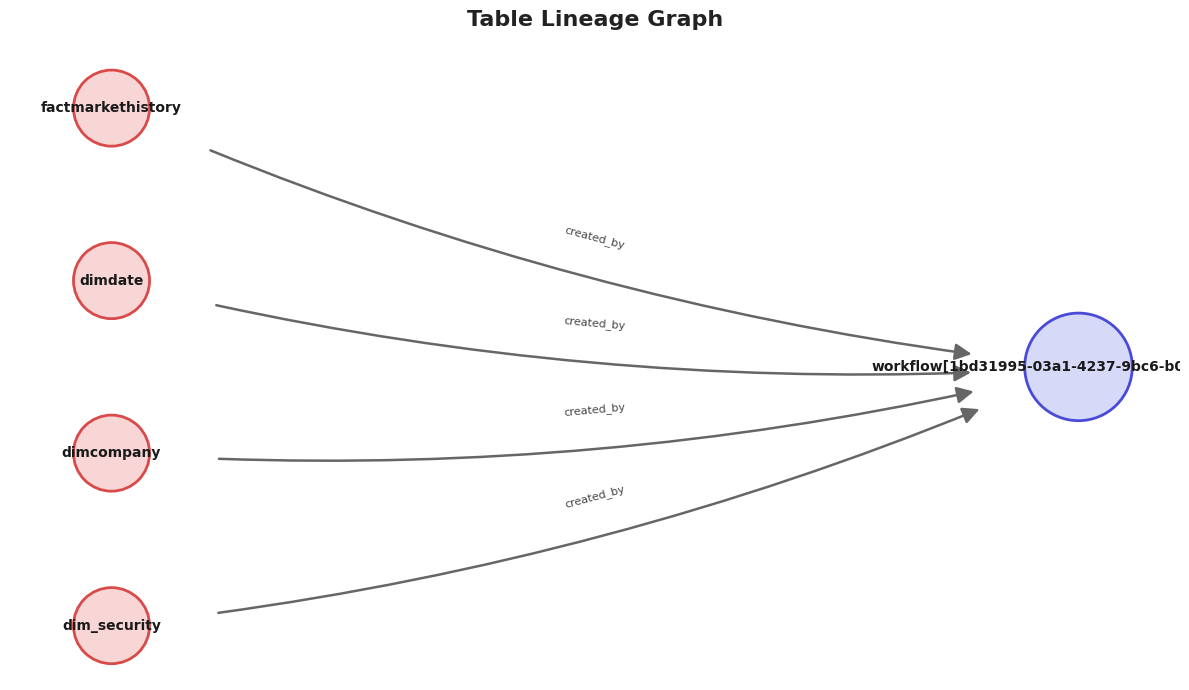

[Round 1] Tool result: Lineage graph rendered: 5 nodes (workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9], factmarkethistory, dim_security, dimcompany, dimdate), 4 edges.

Final answer: Perfect! I found the tables affected by workflow `1bd31995-03a1-4237-9bc6-b01739ce47e9`. 

## Results

The workflow **1bd31995-03a1-4237-9bc6-b01739ce47e9** affects **4 tables**:

1. **tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory**
2. **tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate**
3. **tpcdi.simone_finelli_tpcdi_dbsql_10_gold_market.dim_security**
4. **tpcdi.leo_mao_tpcdi_dbsql_10000.dimcompany**

The visualization above shows the workflow (in the center) connected to all four tables through `created_by` edges, indicating that this workflow is responsible for creating or transforming these tables.


In [256]:
AGENT("What tables are affected by 1bd31995-03a1-4237-9bc6-b01739ce47e9 workflow?")

In [240]:
AGENT("List 10 tables with at least 5 dependencies")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').limit(100).count()).where(select('deg').is(gte(5))).order().by(select('deg'), desc).limit(10)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').limit(100).count()).where(select('deg').is(gte(5))).order().by(select('deg'), desc).limit(10)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').limit(100).count()).where(select('deg').is(gte(5))).order().by(select('deg'), desc).limit(10)"})
[Round 2] Tool result: []

[Round 3] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(10)"})
[Round 3] Tool result: [{"deg": 4000, "id": "table[jack_test.health_demo.my_first_dbt_model]"}, {"deg": 3146, "id": "table[system.__internal_l

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').bothE('lineage').path()"})
[Round 1] Tool result: g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').bothE('lineage').path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').bothE('lineage').path()"})
[Round 1] Tool result: ["path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[ee8e0f06-10fc-3875-b47e-87d010f2e05c]][table[uc_rabi.dbdemos_retail_c360.churn_orders]-lineage->table[uc_rabi.dbdemos_retail_c360.__4e15184c_025b_4a97_9741_732a1badb39b___metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features]]]", "path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[16291993-ab5d-3322-bcee-1159f0089ee7]][table[uc_rabi.dbdemos_retail_c360.churn_orders]-lineage->table[uc_rabi.dbdemos_retail_c360.churn_orders]]]", "path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[

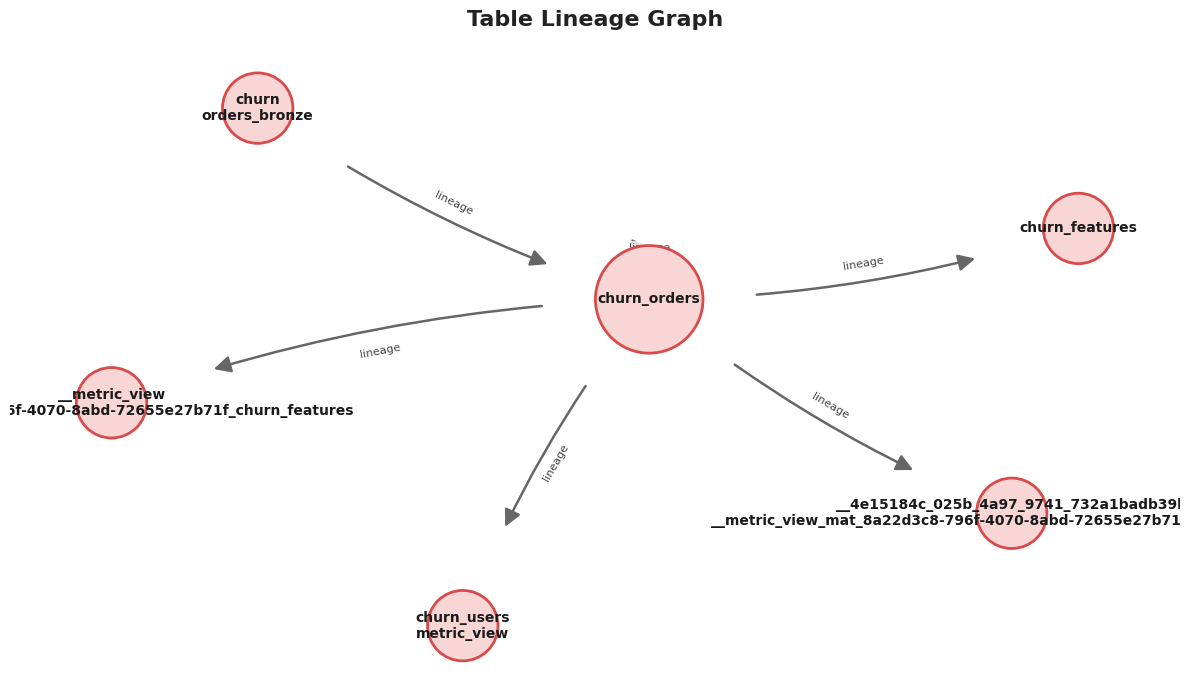

[Round 1] Tool result: Lineage graph rendered: 6 nodes (churn_orders, __4e15184c_025b_4a97_9741_732a1badb39b___metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features, churn_users_metric_view, __metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features, churn_features, churn_orders_bronze), 6 edges.

Final answer: Perfect! I've successfully retrieved and visualized the lineage for the table `uc_rabi.dbdemos_retail_c360.churn_orders`. 

## Summary of Lineage:

The lineage graph shows **6 connected tables** with **6 lineage relationships**:

### **Upstream (Source):**
- `churn_orders_bronze` → `churn_orders` (this is the bronze/raw data feeding into churn_orders)

### **Downstream (Targets):**
The `churn_orders` table feeds into several downstream tables:
1. `churn_features` - likely a feature engineering table
2. `churn_users_metric_view` - a metric view for user churn analysis
3. `__metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features` - a materiali

In [241]:
AGENT("show lineage of uc_rabi.dbdemos_retail_c360.churn_orders")

In [242]:
AGENT("How many unique tables are upsteam of uc_rabi.dbdemos_retail_c360.churn_orders")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').in('lineage').dedup().count()"})
[Round 1] Tool result: g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').in('lineage').dedup().count()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').in('lineage').dedup().count()"})
[Round 1] Tool result: [3]

Final answer: There are **3 unique tables** upstream of `uc_rabi.dbdemos_retail_c360.churn_orders`.

Would you like me to show you what those upstream tables are, or visualize the lineage graph?


[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().path()"})
[Round 1] Tool result: g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().path()"})
[Round 1] Tool result: ["path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[16291993-ab5d-3322-bcee-1159f0089ee7]][table[uc_rabi.dbdemos_retail_c360.churn_orders]-lineage->table[uc_rabi.dbdemos_retail_c360.churn_orders]], v[table[uc_rabi.dbdemos_retail_c360.churn_orders]]]", "path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[395d8ddf-e355-324c-8edf-ecd2f1b89131]][table[uc_rabi.dbdemos_retail_c360.churn_orders_bronze]-lineage->table[uc_rabi.dbdemos_retail_c360.churn_orders]], v[table[uc_rabi.dbdemos_retail_c360.churn_orders_bronze]]]"]

[Round 1] Tool call: visualize

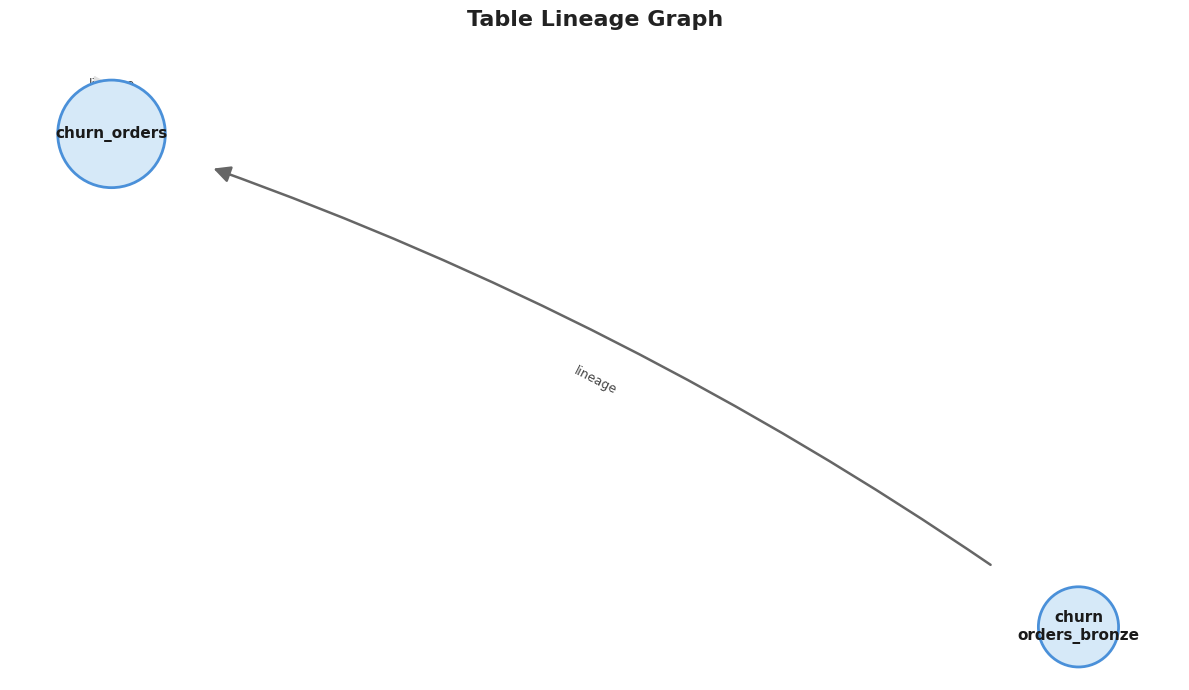

[Round 1] Tool result: Lineage graph rendered: 2 nodes (churn_orders, churn_orders_bronze), 2 edges.

Final answer: Perfect! I found the upstream lineage for `uc_rabi.dbdemos_retail_c360.churn_orders`. 

## Results:

The table **`churn_orders`** has **2 upstream dependencies**:

1. **`uc_rabi.dbdemos_retail_c360.churn_orders_bronze`** - This is a source table that feeds data into `churn_orders`
2. **`uc_rabi.dbdemos_retail_c360.churn_orders`** (self-reference) - The table also has a lineage edge to itself, which typically indicates an incremental update or self-join operation

The visualization above shows the data flow, where:
- **`churn_orders_bronze`** → **`churn_orders`** (the bronze layer feeding into the processed table)
- **`churn_orders`** → **`churn_orders`** (self-referential lineage)

This is a typical pattern in medallion architecture where bronze tables (raw data) are transformed into silver/gold tables (refined data), and the table may also reference itself for incrementa

In [224]:
AGENT("Show upstream lineage of uc_rabi.dbdemos_retail_c360.churn_orders")

In [243]:
AGENT("What is the most connected table")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)"})
[Round 2] Tool result: [{"deg": 4000, "id": "table[jack_test.health_demo.my_first_dbt_model]"}]

Final answer: The most connected table is **`jack_test.health_demo.my_first_dbt_model`** with **4,000 lineage connections** (both upstream and downstream combined).

This table appears to be a central hub in your data lineage graph, likely serving as either a key intermediate transformation table or a widely-used source/target in your data pipelines.


In [174]:
AGENT("What are the top 5 tables with the most downstream lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('table_id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('table_id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('table_id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)"})
[Round 1] Tool result: [{"downstream_count": 4000, "table_id": "table[jack_test.health_demo.my_first_dbt_model]"}, {"downstream_count": 3145, "table_id": "table[system.__internal_logging.payload_logs]"}, {"downstream_count": 1815, "table_id": "table[user_catalog.user_schema.rawesuser]"}, {"downstream_count": 905, "table_id": "table[samples.nyctaxi.trips]"}, {"downstream_count": 687, "table

In [244]:
AGENT("What are the top 5 tables with the most upstream lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)"})
[Round 1] Tool result: [{"id": "table[system.data_classification.__table_statuses]", "upstream_count": 471}, {"id": "table[system.data_classification.__class_tag_applications]", "upstream_count": 239}, {"id": "table[users.ninad_sohoni.product_er_products_canonical_stage]", "upstream_count": 238}, {"id": "table[system.data_classification.results]", "upstream_count": 238}, {"id": "table[roadmap_tool.asana.goal_supporting_wo

In [245]:
AGENT("Show 5 tables that have 5 dependencies ")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)"})
[Round 2] Tool result: [{"deg": 5, "id": "table[remi_demos_claims.fsi_smart_claims.claim]"}, {"deg": 5, "id": "table[remi_demos_claims.fsi_smart_claims.claim]"}, {"deg": 5, "id": "table[remi_imbert_demo.claims.silver_claims]"}, {"deg": 5, "id": "table[renato_pedroso.default.picpay_pix_bronze_ldp]"}, {"deg": 5, "id": "table[renato_pedroso.default.picpay_pix_bronze_ldp]"}]

Final answer: Perfect! I found 5 tables that each have exactly 5 dependencies (lineage connections). Here are the results:

1

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[dbdemos_karla.hls_readmission_demo.condition_occurrence]').repeat(bothE('lineage').otherV().simplePath()).times(4).path().limit(100)"})
[Round 1] Tool result: g.V('table[dbdemos_karla.hls_readmission_demo.condition_occurrence]').repeat(bothE('lineage').otherV().simplePath()).times(4).path().limit(100)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[dbdemos_karla.hls_readmission_demo.condition_occurrence]').repeat(bothE('lineage').otherV().simplePath()).times(4).path().limit(100)"})
[Round 1] Tool result: ["path[v[table[dbdemos_karla.hls_readmission_demo.condition_occurrence]], e[lineage[b20bf4b7-33d9-3392-845d-1a8cd61f7b9e]][table[dbdemos_karla.hls_readmission_demo.conditions]-lineage->table[dbdemos_karla.hls_readmission_demo.condition_occurrence]], v[table[dbdemos_karla.hls_readmission_demo.conditions]], e[lineage[2f3a1031-20d9-3fbf-8d6e-4d5dca362544]][table[dbdemos_karla.hls_readmission_demo.condi

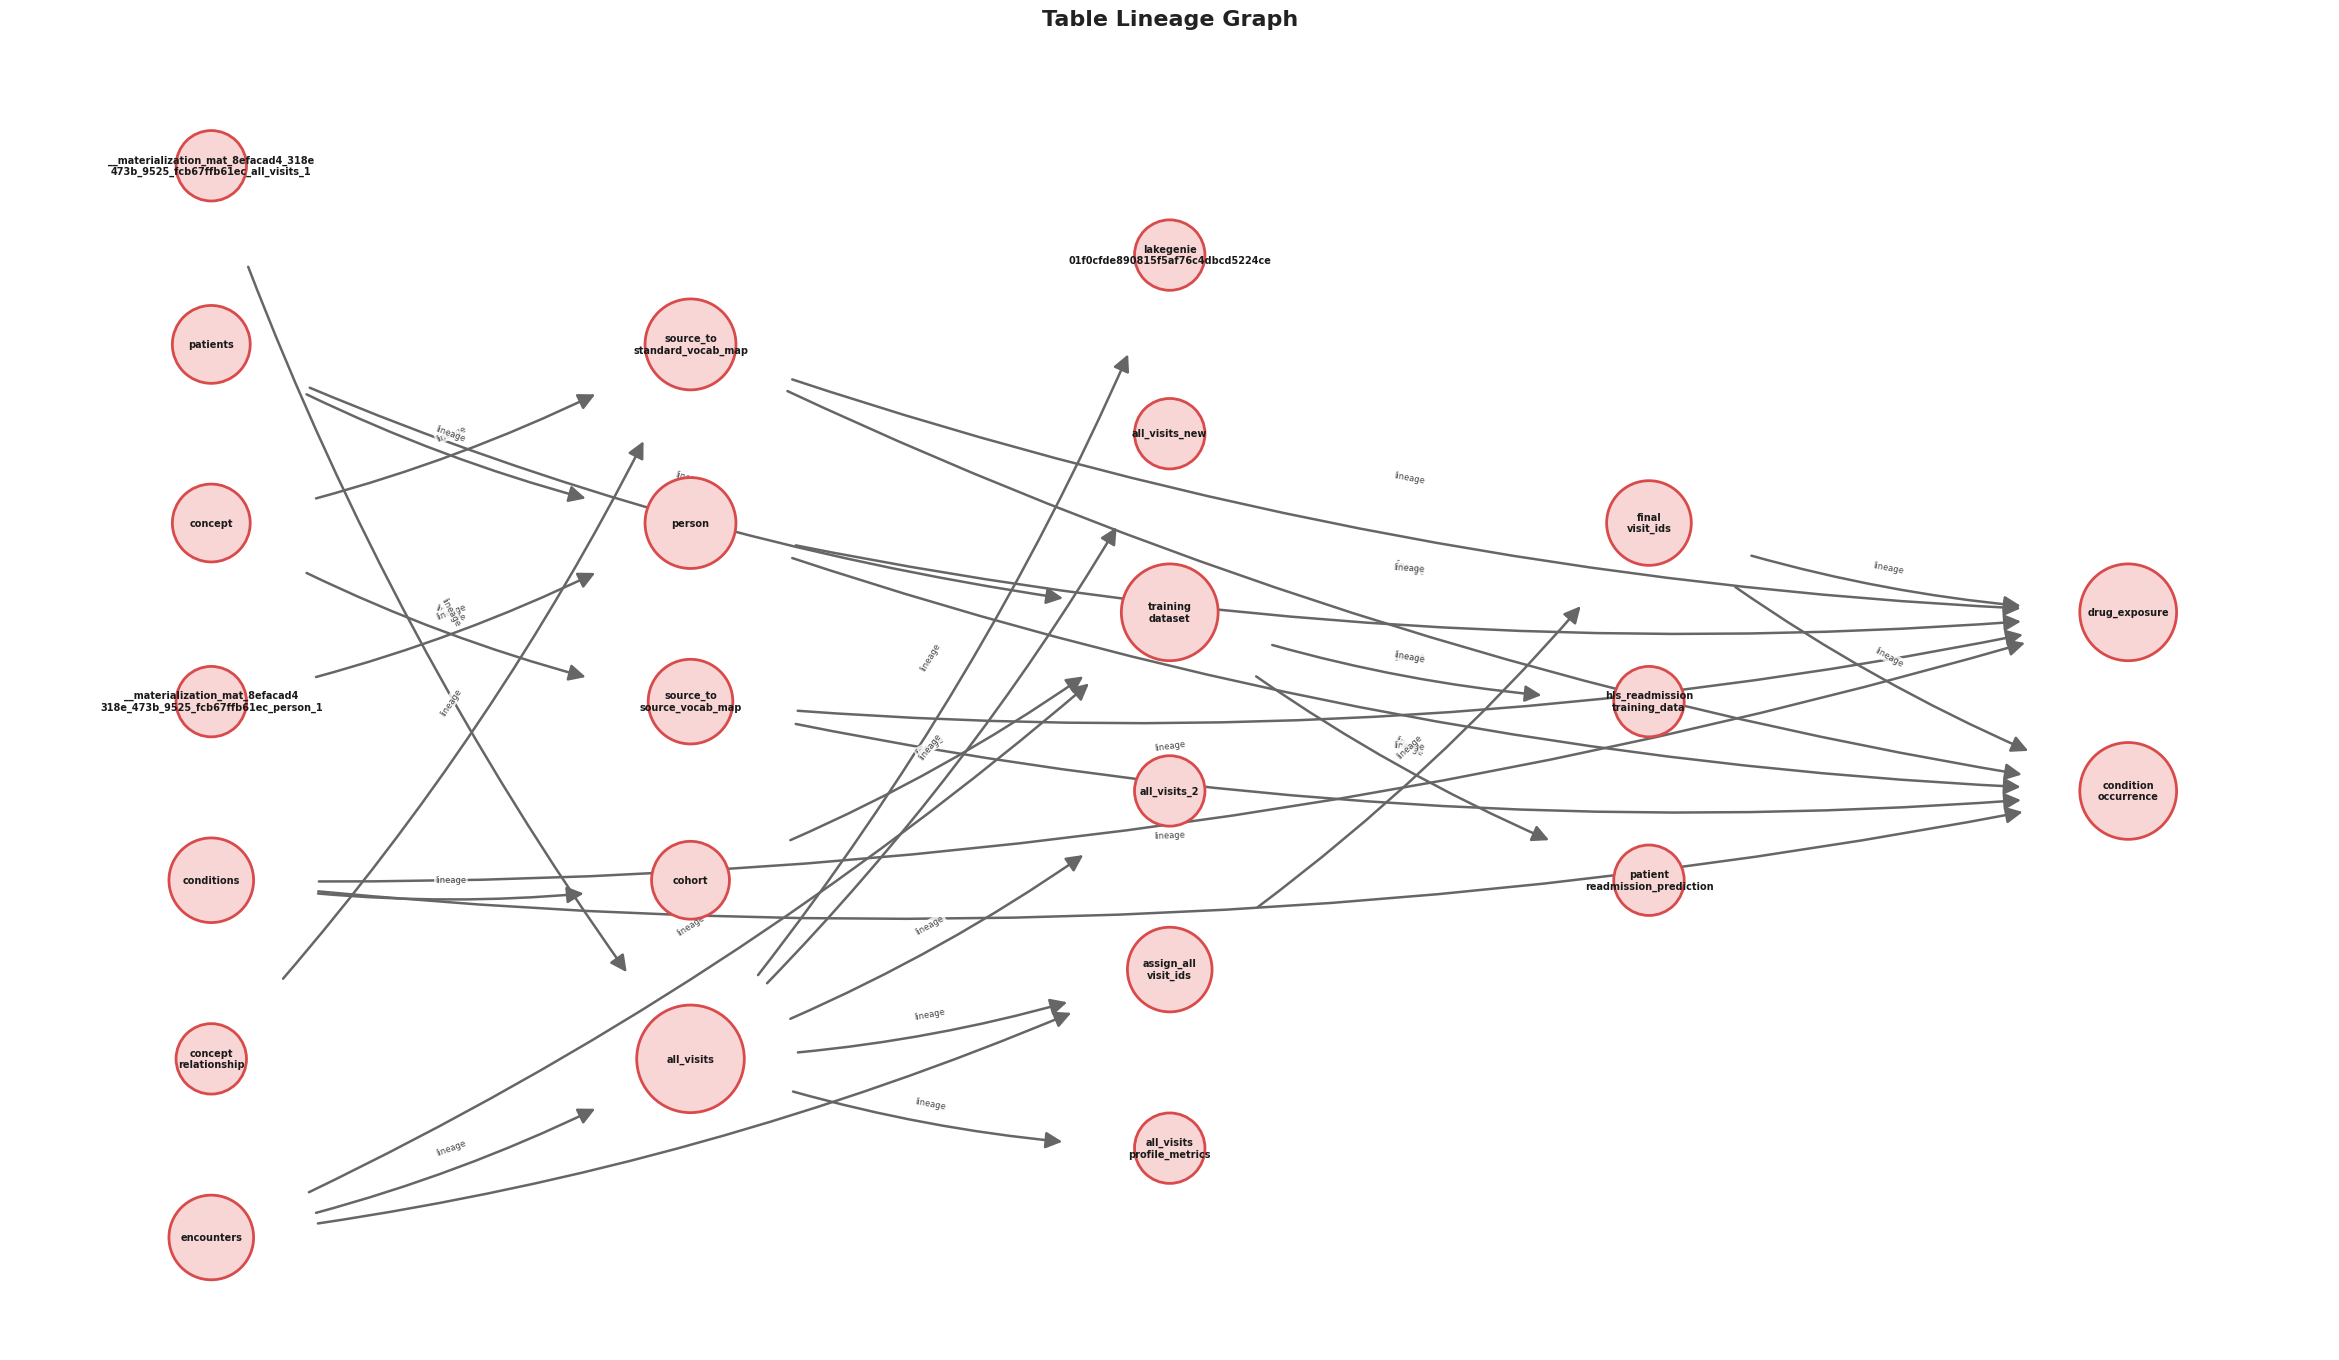

[Round 1] Tool result: Lineage graph rendered: 23 nodes (condition_occurrence, conditions, cohort, training_dataset, patient_readmission_prediction, hls_readmission_training_data, source_to_source_vocab_map, concept, source_to_standard_vocab_map, drug_exposure, person, patients, final_visit_ids, assign_all_visit_ids, encounters, all_visits, all_visits_profile_metrics, all_visits_new, all_visits_2, lakegenie_01f0cfde890815f5af76c4dbcd5224ce, concept_relationship, __materialization_mat_8efacad4_318e_473b_9525_fcb67ffb61ec_person_1, __materialization_mat_8efacad4_318e_473b_9525_fcb67ffb61ec_all_visits_1), 30 edges.

Final answer: Perfect! I've successfully retrieved and visualized the lineage of the table `dbdemos_karla.hls_readmission_demo.condition_occurrence` up to 4 levels. 

## Summary

The query found **100 distinct lineage paths** (limited for performance) showing the data flow relationships up to 4 hops away from the `condition_occurrence` table. The visualization shows:

### Key 

In [246]:
AGENT("Show lineage of dbdemos_karla.hls_readmission_demo.condition_occurrence up to 4 levels")

In [247]:
AGENT("Show upstream lineage of mcutini_tuva.core._stg_claims_medical_claim. also show lineage entity type")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').as('edge').outV().as('upstream').select('upstream', 'edge').by(id()).by(values('entity_type')).limit(20)"})
[Round 1] Tool result: g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').as('edge').outV().as('upstream').select('upstream', 'edge').by(id()).by(values('entity_type')).limit(20)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').as('edge').outV().as('upstream').select('upstream', 'edge').by(id()).by(values('entity_type')).limit(20)"})
[Round 2] Tool result: []

[Round 3] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').id().limit(100)"})
[Round 3] Tool result: ["table[00vsdb.agent_analytics.agents_clean]", "table[00vsdb.default.student_silver]", "table[00vsdb.mlops.openai_payload]", "table[05_08_2025_test_cs_marketing.dbdemos_aibi_


Received error message '{'requestId': '01f3ee61-09f7-4d25-adf6-84ef04d64714', 'status': {'code': 597, 'message': "startup failed:\nScript105.groovy: 1: [Static type checking] - Cannot call org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#is(org.apache.tinkerpop.gremlin.process.traversal.P<java.lang.Object>) with arguments [org.apache.tinkerpop.gremlin.process.traversal.TextP]\n @ line 1, column 37.\n   g.V().hasLabel('table').id().filter(id().is(containing('mcutini_tuva'))).limit(100)\n                                       ^\n\nScript105.groovy: 1: [Static type checking] - Cannot find matching method org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#filter(java.lang.Object). Please check if the declared type is correct and if the method exists.\n @ line 1, column 36.\n   g.V().hasLabel('table').id().filter(id().is(containing('mcutini_tuva'))).limit(100)\n                                      ^\n\nScript105.groovy: 1: [Static type checking]

[Round 4] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').id().filter(id().is(containing('mcutini_tuva'))).limit(100)"})
[Round 4] Tool result: {"error": "Gremlin query error: 597: startup failed:\nScript105.groovy: 1: [Static type checking] - Cannot call org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#is(org.apache.tinkerpop.gremlin.process.traversal.P<java.lang.Object>) with arguments [org.apache.tinkerpop.gremlin.process.traversal.TextP]\n @ line 1, column 37.\n   g.V().hasLabel('table').id().filter(id().is(containing('mcutini_tuva'))).limit(100)\n                                       ^\n\nScript105.groovy: 1: [Static type checking] - Cannot find matching method org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#filter(java.lang.Object). Please check if the declared type is correct and if the method exists.\n @ line 1, column 36.\n   g.V().hasLabel('table').id().filter(id().is(containing('mcutini_tuva'))).limit(100)

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(inE('lineage').outV().simplePath()).emit().path().limit(100)"})
[Round 1] Tool result: g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(inE('lineage').outV().simplePath()).emit().path().limit(100)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(inE('lineage').outV().simplePath()).emit().path().limit(100)"})
[Round 2] Tool result: ["path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_demo.1_dev.gold_traffic_summary]]]", "path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_demo.1_dev.go

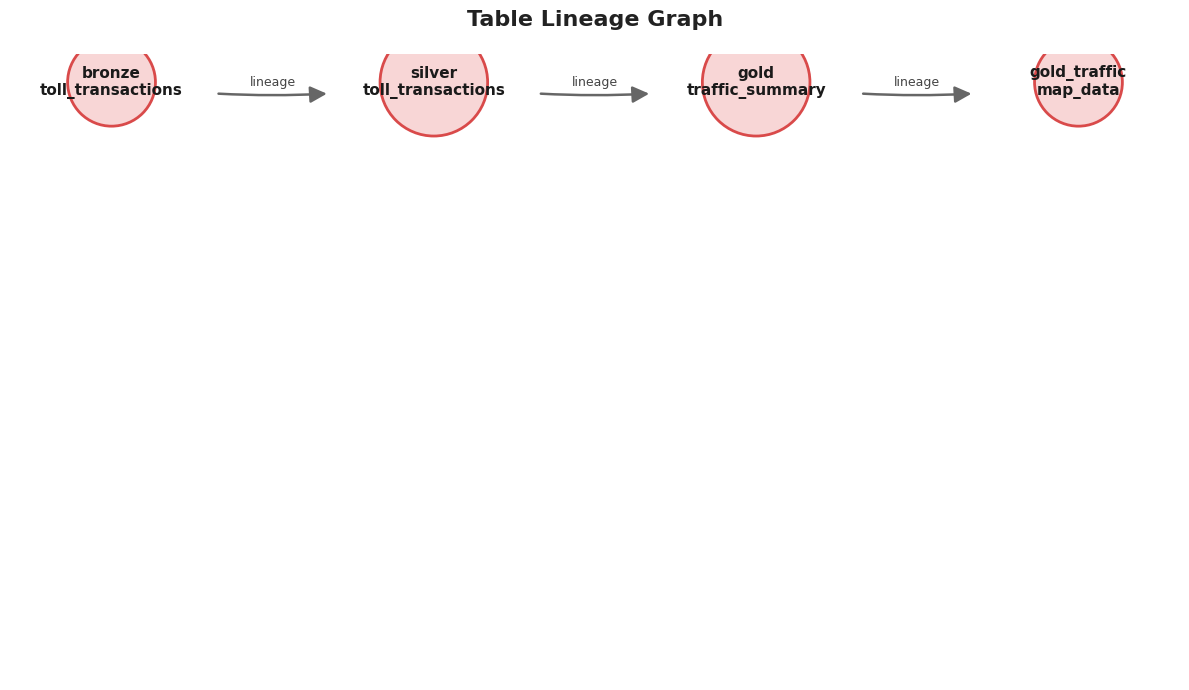

[Round 2] Tool result: Lineage graph rendered: 4 nodes (gold_traffic_map_data, gold_traffic_summary, silver_toll_transactions, bronze_toll_transactions), 3 edges.

Final answer: Perfect! I've found all upstream tables of `407_demo.1_dev.gold_traffic_map_data` recursively. Here's what the lineage shows:

## Upstream Lineage (Recursive)

The data flows through a **3-tier architecture** (Bronze → Silver → Gold):

1. **Direct upstream (1 hop):**
   - `407_demo.1_dev.gold_traffic_summary`

2. **2 hops upstream:**
   - `407_demo.1_dev.silver_toll_transactions`

3. **3 hops upstream (source):**
   - `407_demo.1_dev.bronze_toll_transactions`

## Data Flow Path:
```
bronze_toll_transactions 
    ↓
silver_toll_transactions 
    ↓
gold_traffic_summary 
    ↓
gold_traffic_map_data (your table)
```

The visualization above shows the complete upstream lineage graph with all tables and their relationships. This appears to be a typical medallion architecture pattern where raw data flows from bronze (r

In [248]:
AGENT("recurvively Show all upstream tables of 407_demo.1_dev.gold_traffic_map_data ")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(bothE('lineage').otherV().simplePath()).emit().path().limit(100)"})
[Round 1] Tool result: g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(bothE('lineage').otherV().simplePath()).emit().path().limit(100)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(bothE('lineage').otherV().simplePath()).emit().path().limit(100)"})
[Round 2] Tool result: ["path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_demo.1_dev.gold_traffic_summary]]]", "path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_d

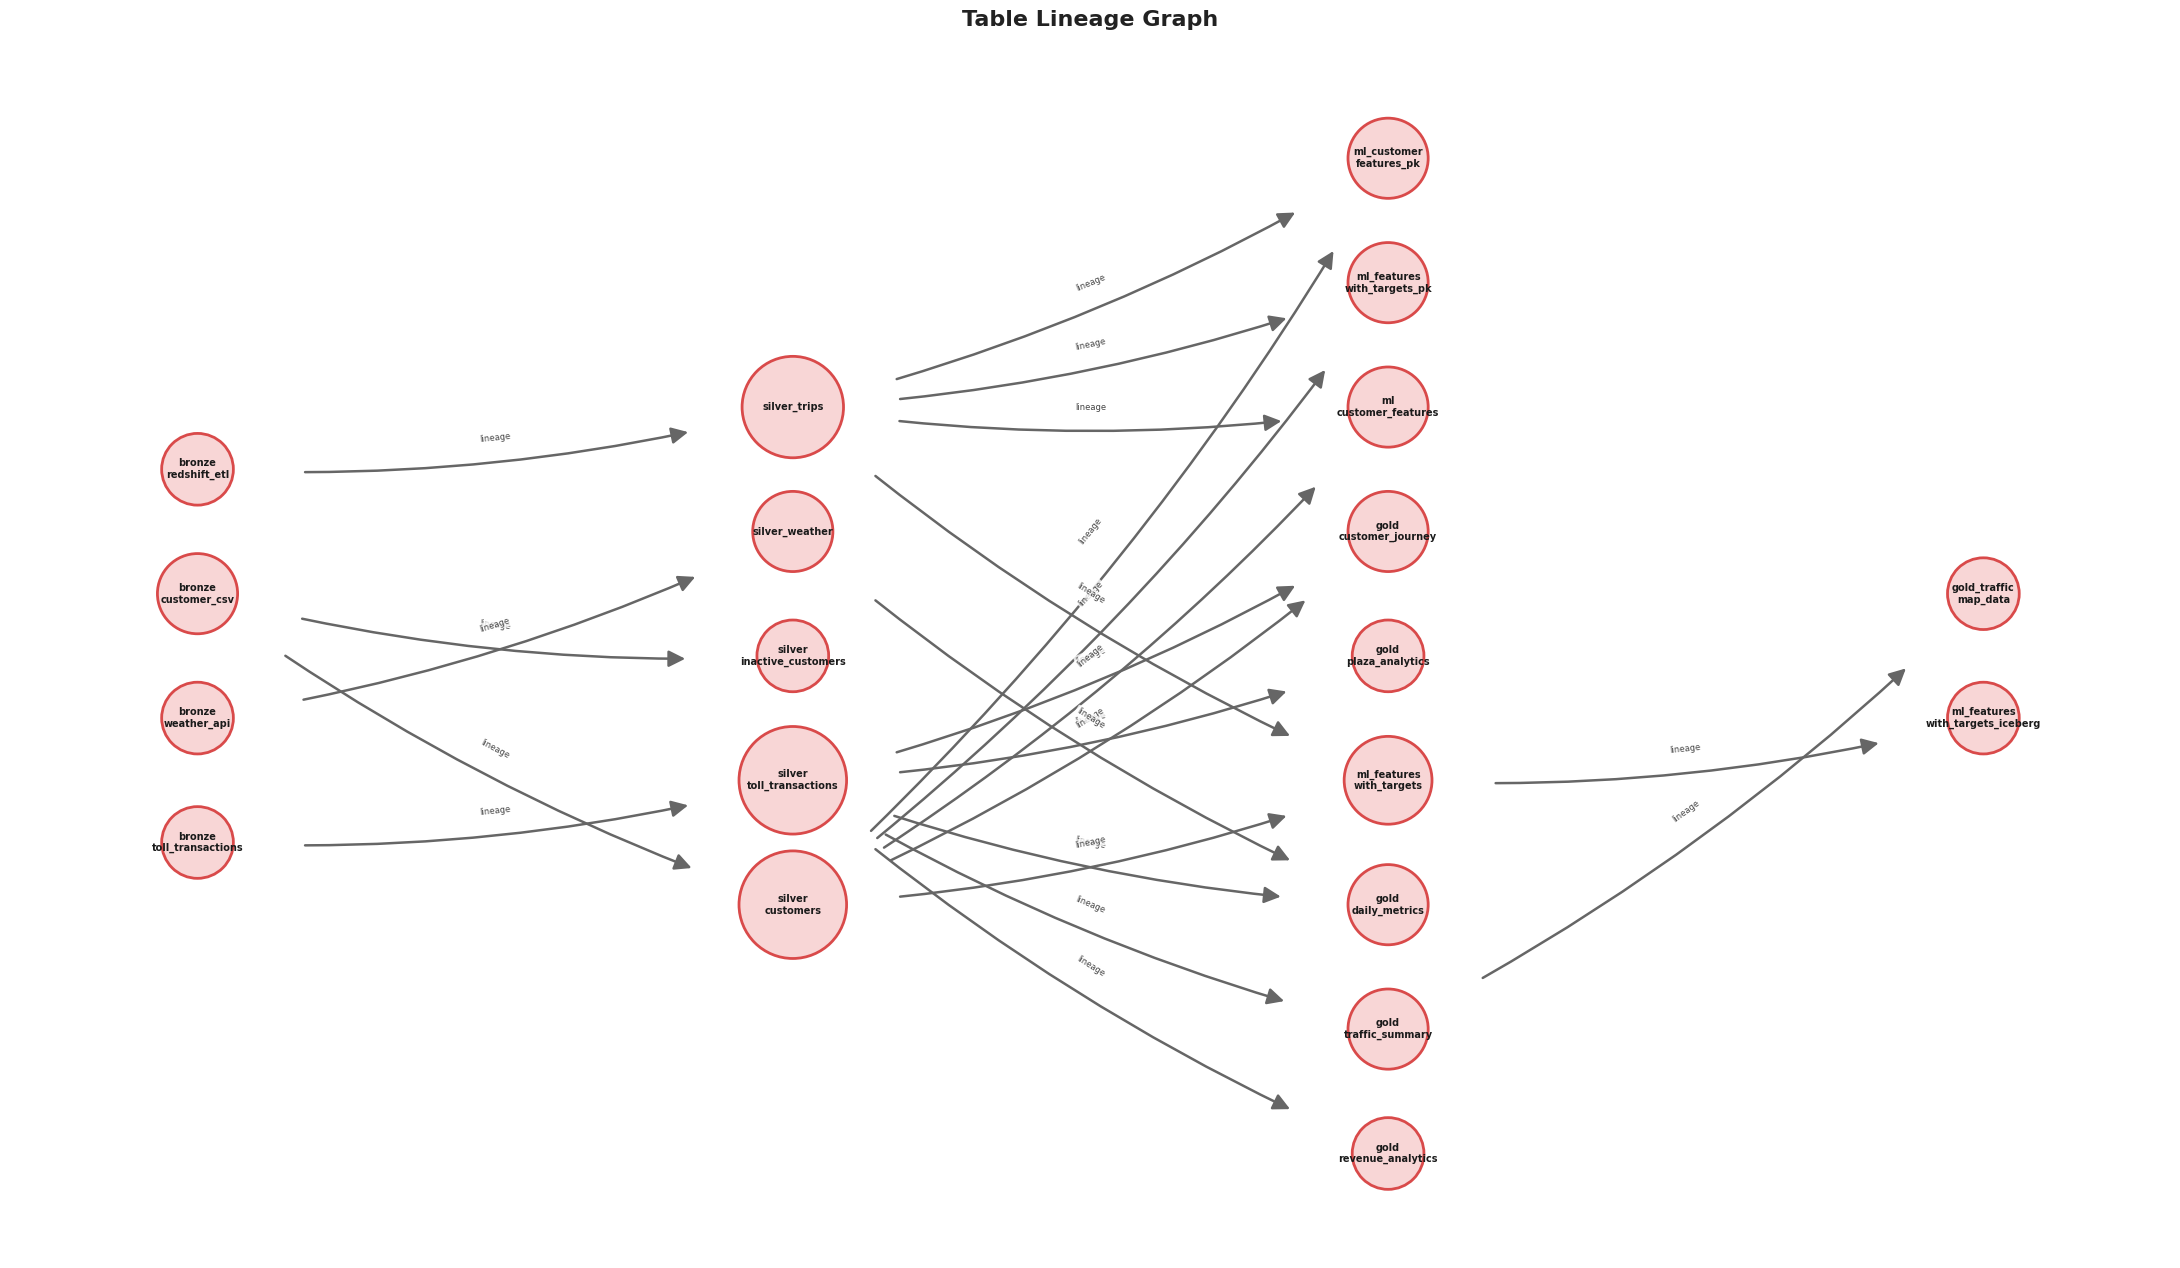

[Round 2] Tool result: Lineage graph rendered: 20 nodes (gold_traffic_map_data, gold_traffic_summary, silver_toll_transactions, gold_customer_journey, bronze_toll_transactions, gold_plaza_analytics, gold_revenue_analytics, gold_daily_metrics, silver_customers, silver_weather, bronze_customer_csv, ml_customer_features, ml_customer_features_pk, ml_features_with_targets, ml_features_with_targets_pk, bronze_weather_api, silver_inactive_customers, silver_trips, ml_features_with_targets_iceberg, bronze_redshift_etl), 22 edges.

Final answer: Perfect! I've successfully retrieved and visualized the complete lineage for `407_demo.1_dev.gold_traffic_map_data`. 

## Summary of Connected Tables:

The lineage graph shows **20 tables** connected to `gold_traffic_map_data` through **22 lineage relationships**:

### **Upstream Tables (Data Sources):**
1. **gold_traffic_summary** (direct upstream)
   - **silver_toll_transactions**
     - **bronze_toll_transactions** (bronze layer)
     - Feeds into mul

In [249]:
AGENT("recurvively Show all  tables that are connected to 407_demo.1_dev.gold_traffic_map_data and it's lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').union(bothE('lineage').path(), outE('created_by').path()).limit(100)"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.agents_clean]').union(bothE('lineage').path(), outE('created_by').path()).limit(100)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').union(bothE('lineage').path(), outE('created_by').path()).limit(100)"})
[Round 1] Tool result: ["path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[651c8d73-4a3c-35e4-96ab-61df5aa15568]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[dcd982d2-5bd9-351f-bb31-0fca2278c9b9]][table[00vsdb.agent_analytics.agents_bronze]-lineage->table[00vsdb.agent_analytics.agents_clean]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[created_by[null]][

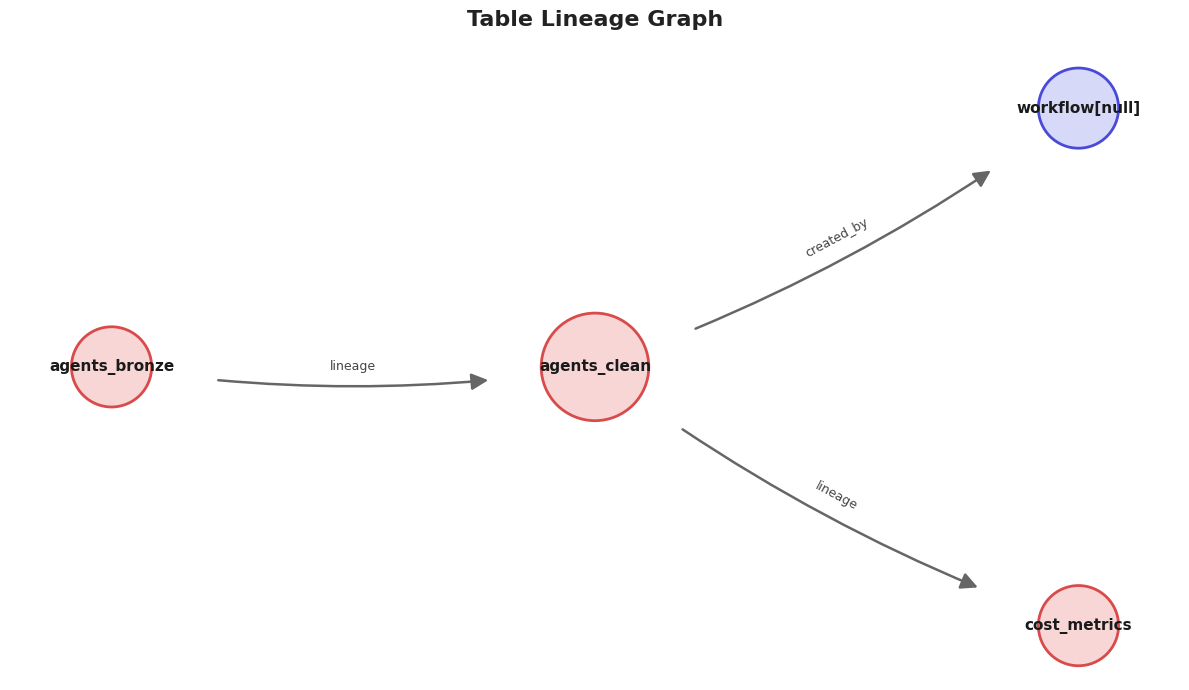

[Round 1] Tool result: Lineage graph rendered: 4 nodes (agents_clean, cost_metrics, agents_bronze, workflow[null]), 3 edges.

Final answer: Perfect! I've retrieved and visualized the lineage for `00vsdb.agent_analytics.agents_clean`. Here's what the graph shows:

## Lineage Summary:

**Table: `00vsdb.agent_analytics.agents_clean`**

### Upstream (Source):
- **`00vsdb.agent_analytics.agents_bronze`** → flows into → `agents_clean`

### Downstream (Target):
- **`agents_clean`** → flows into → **`00vsdb.agent_analytics.cost_metrics`**

### Related Workflow:
- The table has a `created_by` relationship, but it points to `workflow[null]`, which means this table doesn't have an associated workflow recorded in the system (or the workflow information is missing).

The visualization above shows the complete data lineage with:
- **4 nodes**: The main table (agents_clean), its upstream source (agents_bronze), its downstream target (cost_metrics), and a null workflow node
- **3 edges**: One incoming

In [250]:
AGENT("Show lineage of 00vsdb.agent_analytics.agents_clean. include related workflows")

In [251]:
AGENT("Show details of 7281b548-3229-4a52-a9c8-b7eb0068bc90 workflow")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[7281b548-3229-4a52-a9c8-b7eb0068bc90]').project('workflow_id', 'tables_created').by(id()).by(inE('created_by').outV().id().fold()).limit(1)"})
[Round 1] Tool result: g.V('workflow[7281b548-3229-4a52-a9c8-b7eb0068bc90]').project('workflow_id', 'tables_created').by(id()).by(inE('created_by').outV().id().fold()).limit(1)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[7281b548-3229-4a52-a9c8-b7eb0068bc90]').project('workflow_id', 'tables_created').by(id()).by(inE('created_by').outV().id().fold()).limit(1)"})
[Round 1] Tool result: [{"tables_created": ["table[advaitgodbole.benchmark_iceberg.customer_key_lookup]", "table[advaitgodbole.benchmark_iceberg.product_dim]", "table[advaitgodbole.benchmark_iceberg.product_key_lookup]", "table[advaitgodbole.benchmark_iceberg.promotion_dim]", "table[advaitgodbole.benchmark_iceberg._quality_monitoring_summary]", "table[advaitgodbole.benchmark_iceberg.sales_fac

In [252]:
AGENT("What workflows create the most tables. show top 10")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)"})
[Round 1] Tool result: g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)




Received error message '{'requestId': '0aa379b4-4a18-4bc1-a5a6-d118c972999d', 'status': {'code': 597, 'message': "startup failed:\nScript111.groovy: 1: [Static type checking] - Cannot find matching method org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#has(org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<#A extends org.apache.tinkerpop.gremlin.structure.Element, java.lang.Object>, org.apache.tinkerpop.gremlin.process.traversal.P<java.lang.String>). Please check if the declared type is correct and if the method exists.\n @ line 1, column 31.\n   g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)\n                                 ^\n\nScript111.groovy: 1: [Static type checking] - Cannot find matching method java.lang.Object#project(java.lang.String, java.lang.String). Please check if the declared type is co

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)"})
[Round 2] Tool result: {"error": "Gremlin query error: 597: startup failed:\nScript111.groovy: 1: [Static type checking] - Cannot find matching method org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#has(org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<#A extends org.apache.tinkerpop.gremlin.structure.Element, java.lang.Object>, org.apache.tinkerpop.gremlin.process.traversal.P<java.lang.String>). Please check if the declared type is correct and if the method exists.\n @ line 1, column 31.\n   g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)\n                      

In [253]:
AGENT("What workflows create less than 5 tables. show top 10")


Received error message '{'requestId': '354d6412-d6f0-4483-b230-757dd42ecbe7', 'status': {'code': 597, 'message': "startup failed:\nScript113.groovy: 1: [Static type checking] - Cannot find matching method org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#has(org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<#A extends org.apache.tinkerpop.gremlin.structure.Element, java.lang.Object>, org.apache.tinkerpop.gremlin.process.traversal.P<java.lang.String>). Please check if the declared type is correct and if the method exists.\n @ line 1, column 31.\n   g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)\n                                 ^\n\nScript113.groovy: 1: [Static type checking] - Cannot find matching method java.lang.Object#project(java.lang.String, java.lang.String). 

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)"})
[Round 1] Tool result: g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id(), neq('workflow[null]')).project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)"})
[Round 1] Tool result: {"error": "Gremlin query error: 597: startup failed:\nScript113.groovy: 1: [Static type checking] - Cannot find matching method org.apache.tinkerpop.gremlin

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()"})
[Round 1] Tool result: g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()"})
[Round 1] Tool result: ["path[v[workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], e[created_by[1bd31995-03a1-4237-9bc6-b01739ce47e9]][table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate]-created_by->workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], v[table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate]]]", "path[v[workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], e[created_by[1bd31995-03a1-4237-9bc6-b01739ce47e9]][table[tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory]-created_by->workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], v[table[tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory]]]", "path[v[workflo

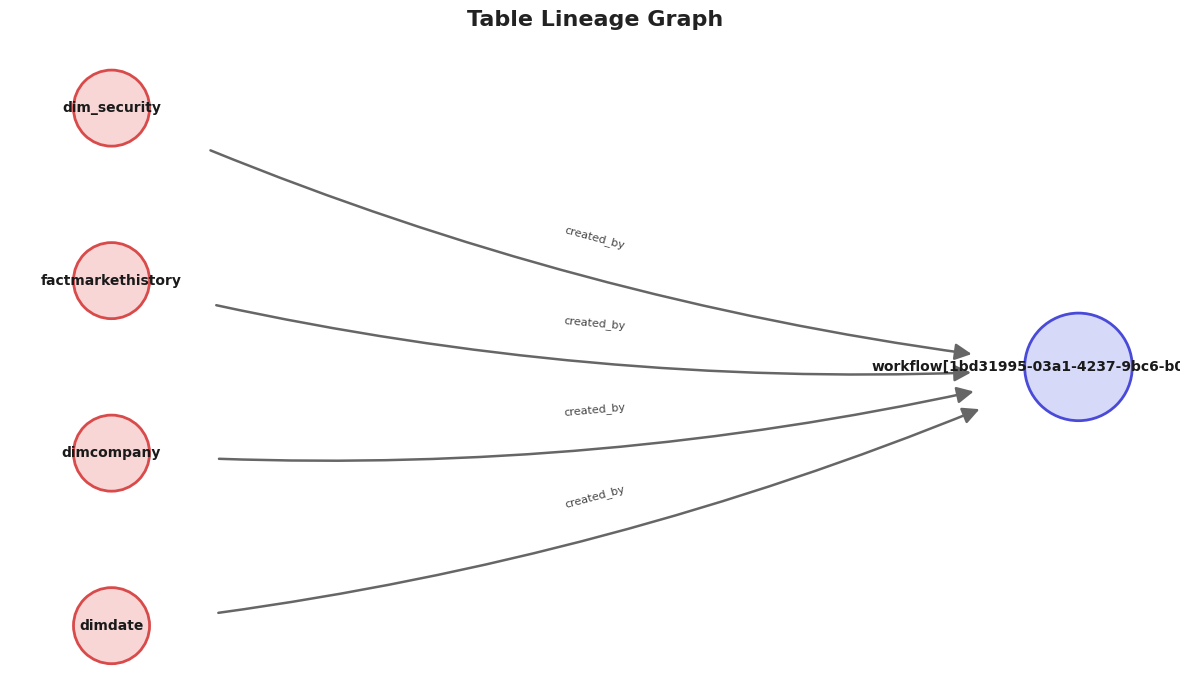

[Round 1] Tool result: Lineage graph rendered: 5 nodes (workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9], dim_security, dimdate, dimcompany, factmarkethistory), 4 edges.

Final answer: Perfect! I found the tables affected by workflow `1bd31995-03a1-4237-9bc6-b01739ce47e9`. 

## Results

The workflow affects **4 tables**:

1. **tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate**
2. **tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory**
3. **tpcdi.leo_mao_tpcdi_dbsql_10000.dimcompany**
4. **tpcdi.simone_finelli_tpcdi_dbsql_10_gold_market.dim_security**

The visualization above shows the workflow (in the center) and all the tables it creates or affects, connected by `created_by` edges. These tables are part of what appears to be a TPC-DI (Transaction Processing Performance Council - Data Integration) benchmark dataset, with dimension tables (dimdate, dimcompany, dim_security) and a fact table (factmarkethistory).


In [254]:
AGENT("What tables are affected by 1bd31995-03a1-4237-9bc6-b01739ce47e9 workflow?")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)"})
[Round 1] Tool result: g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)"})
[Round 1] Tool result: []

[Round 1] Tool call: visualize_lineage({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)"})
[Round 1] Tool result: {"message": "Query returned no results \u2014 nothing to visualize."}

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').out


Received error message '{'requestId': '59e5c0f5-9f67-4bf7-81f9-ca72d6ec1f65', 'status': {'code': 597, 'message': "startup failed:\nScript118.groovy: 1: [Static type checking] - Cannot call <E2> org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#union(org.apache.tinkerpop.gremlin.process.traversal.Traversal<? extends java.lang.Object, E2>[]) with arguments [org.apache.tinkerpop.gremlin.process.traversal.Traversal<?, ?>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>]\n @ line 1, column 85.\n   inE('created_by').outV().union(identity(\n                                 ^\n\nScript118.groovy: 1: [Static type checking] - Cannot find matching method java.lang.Object#dedup(). Please check i

[Round 3] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().union(identity(), outE('lineage').inV(), outE('lineage').inV().outE('lineage').inV()).dedup().id().limit(100)"})
[Round 3] Tool result: {"error": "Gremlin query error: 597: startup failed:\nScript118.groovy: 1: [Static type checking] - Cannot call <E2> org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#union(org.apache.tinkerpop.gremlin.process.traversal.Traversal<? extends java.lang.Object, E2>[]) with arguments [org.apache.tinkerpop.gremlin.process.traversal.Traversal<?, ?>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>]\n @ line 1, column 85.\n   i

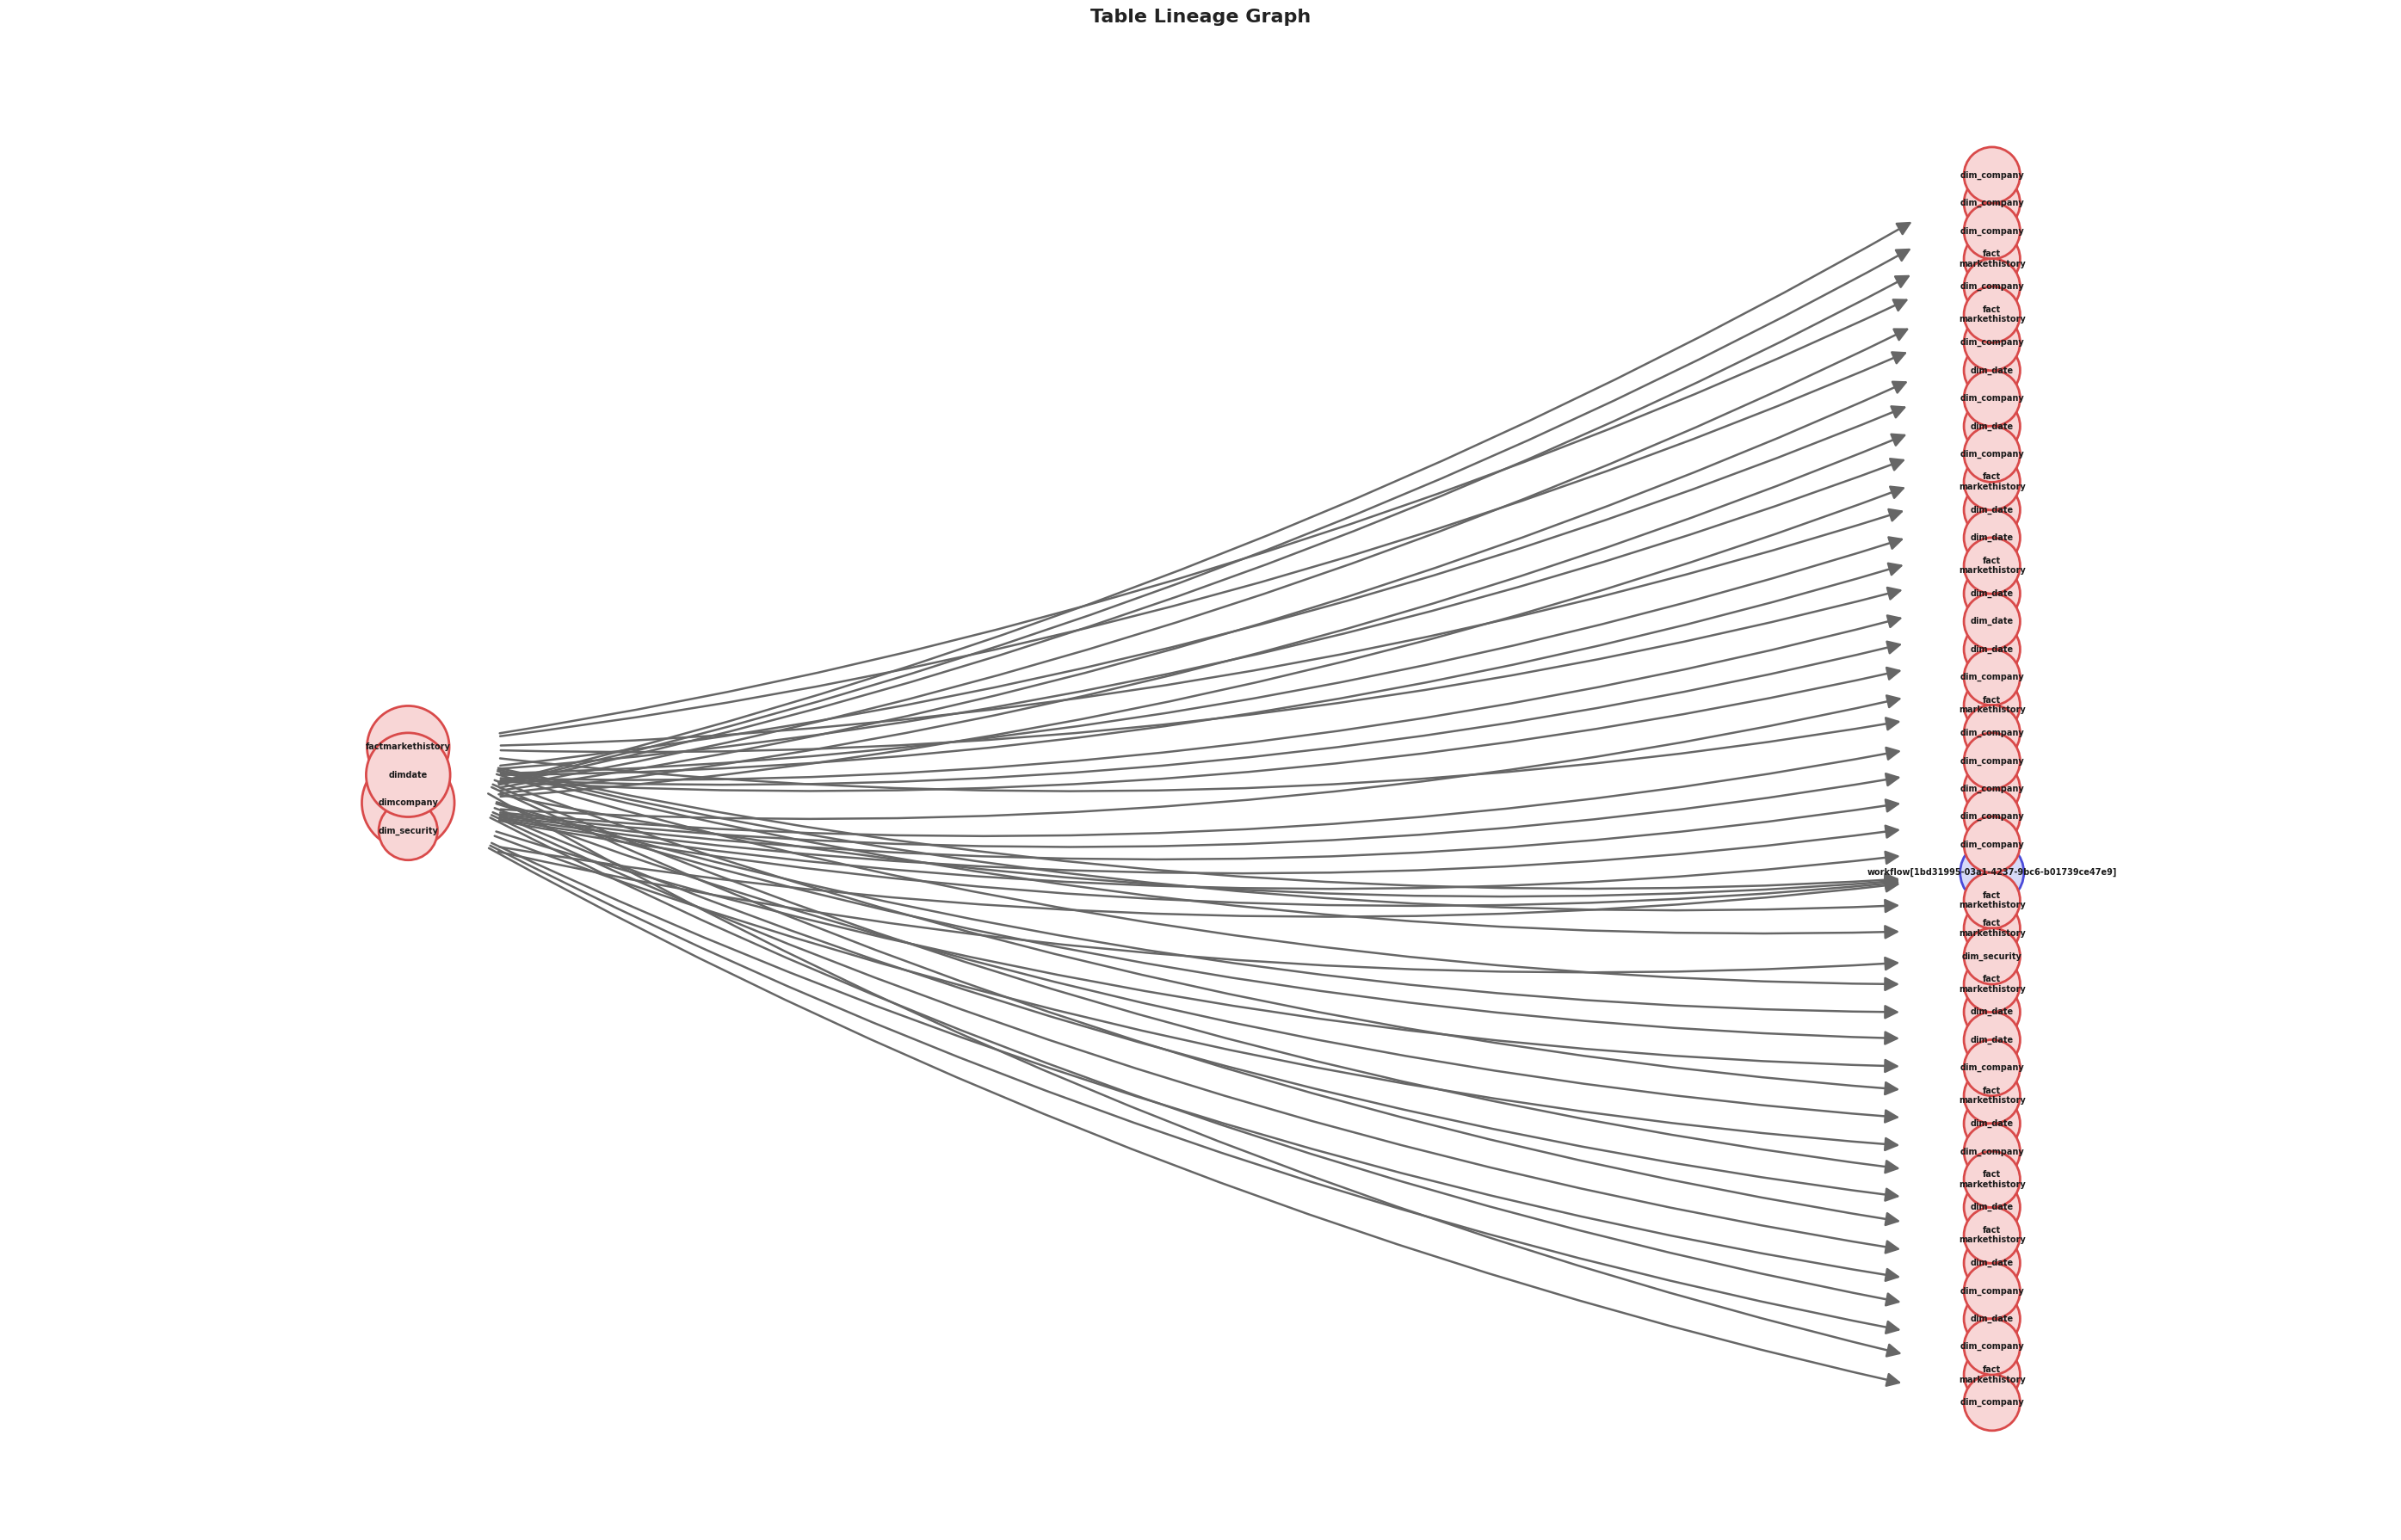

[Round 4] Tool result: Lineage graph rendered: 49 nodes (workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9], factmarkethistory, dimcompany, dim_security, dimdate, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, fact_markethistory, fact_markethistory, fact_markethistory, dim_company, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, fact_markethistory, fact_markethistory, fact_markethistory, dim_security), 48 edges.

[Round 5] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().emit().repeat(outE('lineage').inV()).times(2).dedup().id().limit(100)"})
[Ro

In [255]:
AGENT("What tables are affected by 1bd31995-03a1-4237-9bc6-b01739ce47e9 workflow? Recusively show all tables until 2 levels")

In [257]:
AGENT("Show workflows that don't affect any tables")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('workflow').not(hasId('workflow[null]')).not(inE('created_by')).id().limit(20)"})
[Round 1] Tool result: g.V().hasLabel('workflow').not(hasId('workflow[null]')).not(inE('created_by')).id().limit(20)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').not(hasId('workflow[null]')).not(inE('created_by')).id().limit(20)"})
[Round 1] Tool result: []

Final answer: The query returned an empty result, which means **there are no workflows that don't affect any tables** (excluding the null workflow).

This indicates that all valid workflows in your graph have at least one `created_by` edge connecting them to a table they created or transformed. This is actually a good sign - it means all your tracked workflows have produced some output tables.

If you'd like, I can show you:
- A count of all workflows in the system
- Which workflows affect the most tables
- Or any other workflow-related analy

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id, neq('workflow[null]')).inE('created_by').has('created_by', 'rob.bajra@databricks.com').outV().path().limit(100)"})
[Round 1] Tool result: g.V().hasLabel('workflow').has(id, neq('workflow[null]')).inE('created_by').has('created_by', 'rob.bajra@databricks.com').outV().path().limit(100)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id, neq('workflow[null]')).inE('created_by').has('created_by', 'rob.bajra@databricks.com').outV().path().limit(100)"})
[Round 2] Tool result: ["path[v[workflow[3d8b6921-1119-42fc-8f1e-45e27d739e1f]], e[created_by[3d8b6921-1119-42fc-8f1e-45e27d739e1f]][table[rob_cat.puppygraph.table_lineage]-created_by->workflow[3d8b6921-1119-42fc-8f1e-45e27d739e1f]], v[table[rob_cat.puppygraph.table_lineage]]]", "path[v[workflow[3d8b6921-1119-42fc-8f1e-45e27d739e1f]], e[created_by[3d8b6921-1119-42fc-8f1e-45e27d739e1f]][table[rob_cat.puppygraph.ta

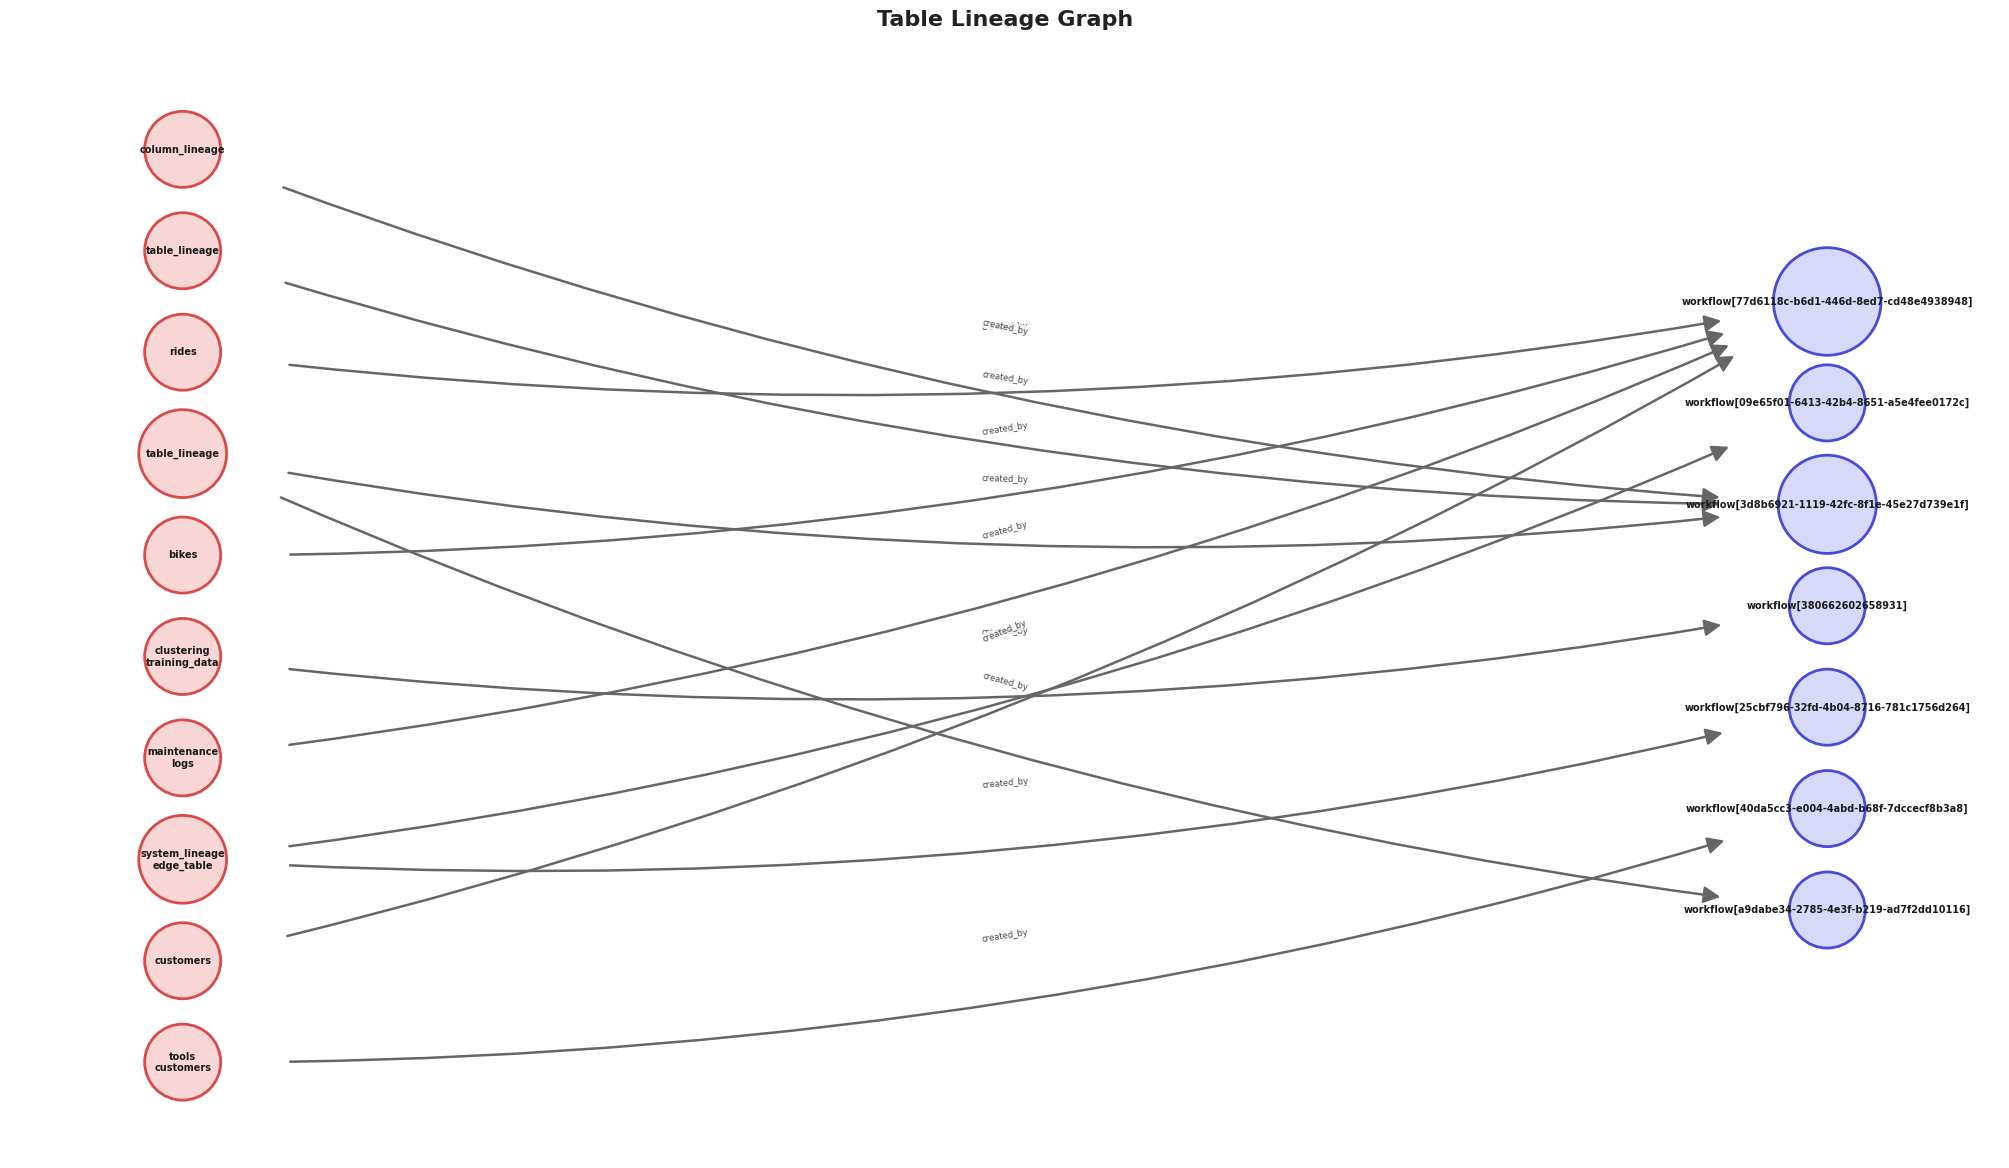

[Round 3] Tool result: Lineage graph rendered: 17 nodes (workflow[40da5cc3-e004-4abd-b68f-7dccecf8b3a8], tools_customers, workflow[09e65f01-6413-42b4-8651-a5e4fee0172c], system_lineage_edge_table, workflow[25cbf796-32fd-4b04-8716-781c1756d264], workflow[a9dabe34-2785-4e3f-b219-ad7f2dd10116], table_lineage, workflow[3d8b6921-1119-42fc-8f1e-45e27d739e1f], workflow[77d6118c-b6d1-446d-8ed7-cd48e4938948], bikes, workflow[380662602658931], clustering_training_data, customers, maintenance_logs, rides, table_lineage, column_lineage), 12 edges.

[Round 4] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').has(id, neq('workflow[null]')).inE('created_by').has('created_by', 'rob.bajra@databricks.com').outV().dedup().id().limit(100)"})
[Round 4] Tool result: ["table[system.access.column_lineage]", "table[users.rob_bajra.bikes]", "table[users.rob_bajra.clustering_training_data]", "table[users.rob_bajra.customers]", "table[jinlinhe_demo.graph_schema.system_lineage_edge_table]", 

In [ ]:
AGENT("Show workflows created by rob.bajra@databricks.com. also show what tables the workflows affect ")